In [ ]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

In [ ]:
def prepare_gene_mutations(filepath, gene_symbol, sep="\t"):
    """
    Load mutation data, filter missense variants for a given gene,
    parse amino acid changes, and summarize counts per residue.
    
    Returns
    -------
    pandas.DataFrame with columns:
        Residue (int), Mutations (str), Count (int)
    """
    df = pd.read_csv(filepath, sep=sep)

    # Filter to gene + missense
    df = df[
        (df["GENE_SYMBOL"] == gene_symbol) &
        (df["MUTATION_DESCRIPTION"] == "missense_variant")
    ].copy()

    residues, mutations = [], []

    for aa_change in df["MUTATION_AA"]:
        if not isinstance(aa_change, str) or not aa_change.startswith("p."):
            continue

        mut = aa_change[2:]  # Remove "p."
        if mut in {"?", ""} or "*" in mut:  # Skip unknown/nonsense
            continue
        if mut[0] == mut[-1]:  # Skip synonymous
            continue

        # Extract residue number
        residue_match = re.search(r"\d+", mut)
        if not residue_match:
            continue
        residue = int(residue_match.group())

        residues.append(residue)
        mutations.append(mut)

    if not residues:
        return pd.DataFrame(columns=["Residue", "Mutations", "Count"])

    # Build summary
    data = pd.DataFrame({"Residue": residues, "Mutation": mutations})
    summary = (
        data.groupby("Residue")
        .agg(Mutations=("Mutation", lambda x: "/".join(sorted(set(x)))),
             Count=("Mutation", "count"))
        .reset_index()
    )

    return summary

In [ ]:
def clusters_to_density(clusters, protein_length):
    density = np.zeros(protein_length + 1, dtype=int)

    for _, row in clusters.iterrows():
        start = max(0, int(row["start"]))
        end = min(protein_length, int(row["end"]))
        density[start:end] += 1

    return density

In [ ]:
def plot_lollipop(summary_df,
                  protein_length,
                  title=None,
                  domains=None,
                  clusters=None):
    """
    Protein lollipop plot with domains and cluster heatmap bar.
    """

    if summary_df is None or summary_df.empty:
        print("⚠️ No mutations to plot")
        return

    # Data 
    x = summary_df["Residue"].astype(int)
    y = summary_df["Count"].astype(int)
    labels = summary_df["Mutations"]
    ymax = y.max()

    # Figure
    fig, ax = plt.subplots(figsize=(16, 6))

    # Lollipop stems
    markers, stemlines, baseline = ax.stem(x, y)
    plt.setp(markers, markersize=9,
             markeredgecolor="k", markeredgewidth=1)
    plt.setp(stemlines, linewidth=1.5, color="k")
    plt.setp(baseline, visible=False)

    # Backbone
    backbone_y = -0.2
    ax.hlines(
        y=backbone_y,
        xmin=0,
        xmax=protein_length,
        linewidth=6,
        color="#808080",
        zorder=2,
    )

    # Domains
    if domains:
        box_height = 0.25
        label_y = backbone_y - 0.45

        for d in domains:
            start = max(0, int(d["start"]))
            end = min(protein_length, int(d["end"]))
            if end <= start:
                continue

            rect = patches.Rectangle(
                (start, backbone_y - box_height / 2),
                end - start,
                box_height,
                facecolor=d.get("color", "#c9e4ff"),
                edgecolor="k",
                linewidth=2,
                zorder=3,
                clip_on=False,
            )
            ax.add_patch(rect)

            if d.get("name"):
                ax.text(
                    (start + end) / 2,
                    label_y,
                    d["name"],
                    ha="center",
                    va="center",
                    fontsize=10,
                    weight="bold",
                    clip_on=False,
                    zorder=4,
                )

    # Cluster heatmap
    if clusters is not None and not clusters.empty:
        density = clusters_to_density(clusters, protein_length)

        if density.max() > 0:
            density = density / density.max()

        heat = density[np.newaxis, :]

        heat_y_center = -1.4
        heat_height = 0.8

        extent = [
            0,
            protein_length,
            heat_y_center - heat_height / 2,
            heat_y_center + heat_height / 2,
        ]

        pale_reds = plt.cm.Reds.resampled(256)
        pale_reds = LinearSegmentedColormap.from_list(
            "pale_reds", pale_reds(np.linspace(0.0, 0.75, 256))
        )

        ax.imshow(
            heat,
            aspect="auto",
            extent=extent,
            cmap=pale_reds, 
            origin="lower",
            interpolation="nearest",
            zorder=1,
        )

        ax.text(
        240, 
        -1.5,
        "overlayed clusters",
        ha="center",
        va="center",
        fontsize=12,
        color="black",
        zorder=2,
        weight="bold",
            )   
        
    # Mutation labels
    for xi, yi, lab in zip(x, y, labels):
        if yi >= 2:
            ax.text(
                xi,
                yi + 0.15,
                lab,
                ha="left",
                va="bottom",
                fontsize=9,
                rotation=45,
            )

    # Axes styling
    ax.set_xlim(0, protein_length+10)
    ax.set_ylim(-2, ymax + 2.1)
    ax.set_yticks([t for t in ax.get_yticks() if t >= 0])

    ax.set_xlabel("Residue", fontsize=13)
    ax.set_ylabel("Number of Mutations", fontsize=13)

    if title:
        ax.set_title(title, fontsize=15)

    for spine in ax.spines.values():
        spine.set_linewidth(2)

    ax.tick_params(width=2)

    # Manual layout (no tight_layout) ---
    plt.subplots_adjust(
        left=0.06,
        right=0.98,
        bottom=0.28,
        top=0.88,
    )
    plt.savefig('KCNA5.svg', bbox_inches='tight')
    plt.show()

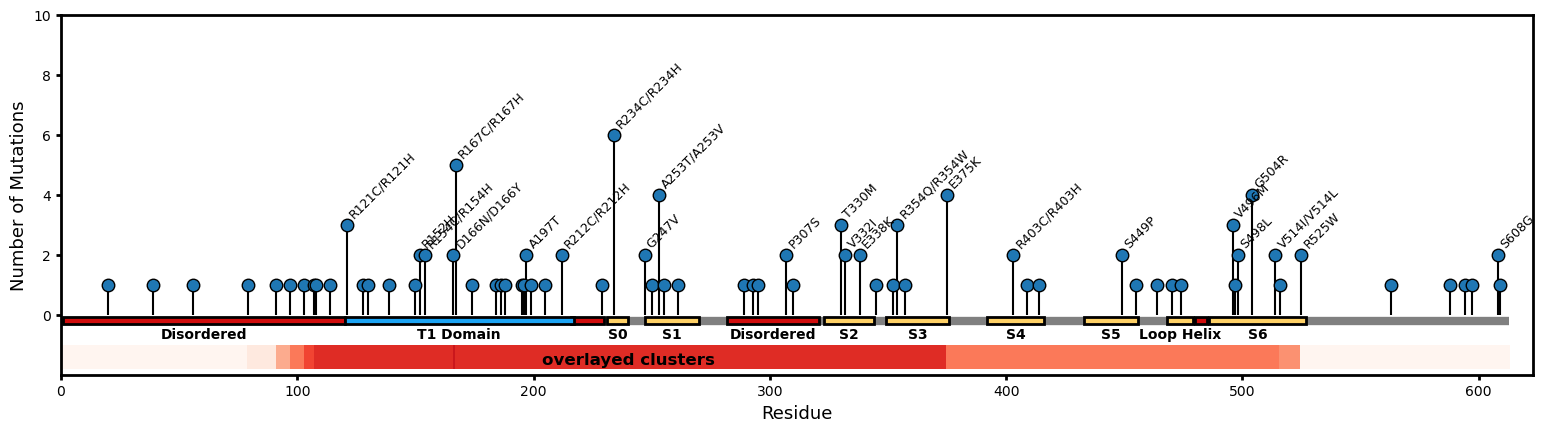

In [ ]:
file = "data/cosmic_LI_AC_filtered.tsv"
KCNA5_domains = [
    {"name": "Disordered", "start": 1, "end": 120, "color": "#d00d0d"},
    {"name": "", "start": 216, "end": 230, "color": "#d00d0d"},
    {"name": "S0", "start": 231, "end": 240, "color": "#ffd166"},
    {"name": "S1", "start": 247, "end": 270, "color": "#ffd166"},
    {"name": "Disordered", "start": 282, "end": 321, "color": "#d00d0d"},
    {"name": "S2", "start": 323, "end": 344, "color": "#ffd166"},
    {"name": "S3", "start": 349, "end": 376, "color": "#ffd166"},
    {"name": "S4", "start": 392, "end": 416, "color": "#ffd166"},
    {"name": "S5", "start": 433, "end": 456, "color": "#ffd166"},
    {"name": "Loop Helix", "start": 468, "end": 479, "color": "#ffd166"},
    {"name": "", "start": 480, "end": 485, "color": "#d00d0d"},
    {"name": "S6", "start": 486, "end": 527, "color": "#ffd166"},
    {"name": "T1 Domain", "start": 120, "end": 217, "color": "#1ca4f4"}
]


clusters = pd.read_csv("KCNA5_clusters.csv")
df = prepare_gene_mutations(file, "KCNA5")
plot_lollipop(df, 613, domains = KCNA5_domains, clusters=clusters)

In [ ]:
filepath = "data/cosmic_LI_AC_filtered.tsv"
gene_symbol = "KCNA5"
sep="\t"

df = pd.read_csv(filepath, sep=sep)

# Filter to gene + missense
df = df[
    (df["GENE_SYMBOL"] == gene_symbol) &
    (df["MUTATION_DESCRIPTION"] == "missense_variant")
].copy()

residues, mutations = [], []

for aa_change in df["MUTATION_AA"]:
    if not isinstance(aa_change, str) or not aa_change.startswith("p."):
        continue

    mut = aa_change[2:]  # remove "p."
    if mut in {"?", ""} or "*" in mut:  # skip unknown/nonsense
        continue
    if mut[0] == mut[-1]:  # skip synonymous
        continue

    # Extract residue number
    residue_match = re.search(r"\d+", mut)
    if not residue_match:
        continue
    residue = int(residue_match.group())

    residues.append(residue)
    mutations.append(mut)



# Build summary
data = pd.DataFrame({"Residue": residues, "Mutation": mutations}).sort_values("Residue")




In [45]:
data.to_csv("cosmic_KCNA5.csv")